In [1]:
from pathlib import Path
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import echopype as ep

In [2]:
data_path = Path("/Users/wujung/code_git/echodataflow/temp_bio")
csv_path = data_path / "bio_csv"
NASC_path = data_path / "nasc_zarr"

In [3]:
ds_NASC = xr.open_zarr(NASC_path / "win_1720383165_1720385660_NASC.zarr")

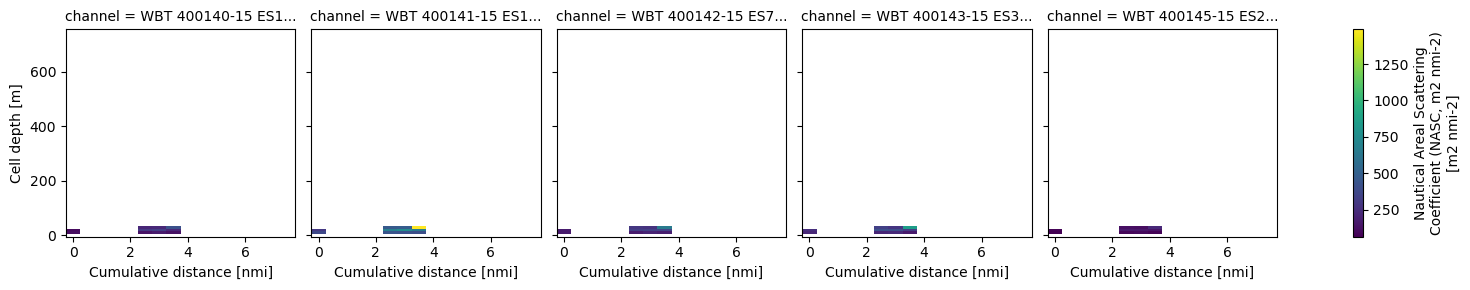

In [4]:
ds_NASC["NASC"].plot(x="distance", col="channel")

In [5]:
ds_NASC

<xarray.Dataset> Size: 50kB
Dimensions:            (channel: 5, distance: 16, depth: 76)
Coordinates:
  * channel            (channel) <U25 500B 'WBT 400140-15 ES120-7C_ES' ... 'W...
  * depth              (depth) float64 608B 0.0 10.0 20.0 ... 730.0 740.0 750.0
  * distance           (distance) float64 128B 0.0 0.5 1.0 1.5 ... 6.5 7.0 7.5
Data variables:
    NASC               (channel, distance, depth) float64 49kB dask.array<chunksize=(5, 16, 76), meta=np.ndarray>
    frequency_nominal  (channel) float64 40B dask.array<chunksize=(5,), meta=np.ndarray>
    latitude           (distance) float64 128B dask.array<chunksize=(16,), meta=np.ndarray>
    longitude          (distance) float64 128B dask.array<chunksize=(16,), meta=np.ndarray>
    ping_time          (distance) datetime64[ns] 128B dask.array<chunksize=(16,), meta=np.ndarray>
Attributes:
    Conventions:           CF-1.7,ACDD-1.3
    geospatial_lat_max:    38.94203
    geospatial_lat_min:    38.82878
    geospatial_lon_max:    -124.58387
    geospatial_lon_min:    -124.67095
    processing_level:      Level 4
    processing_level_url:  https://echopype.readthedocs.io/en/stable/processi...
    time_coverage_end:     2024-07-07T20:54:20.000000000Z
    time_coverage_start:   2024-07-07T20:12:45.000000000Z

In [6]:
from core import GRID_PARAMS

In [7]:
from grid import create_grid_from_bounds, plot_grid

In [8]:
# Create the full grid
grid_cells, coastline, boundary = create_grid_from_bounds(
    bounds=GRID_PARAMS["bounds"], 
    resolution=GRID_PARAMS["resolution"],
    projection=GRID_PARAMS["projection"],
    coastline_resolution="10m",
    area_threshold=5
)

In [9]:
grid_cells

,geometry,grid_x,grid_y,area
0,"POLYGON ((-117.25452 32.76713, -117.25388 32.7...",38,1,491.943240
1,"POLYGON ((-117.4894 32.78924, -117.49448 32.75...",37,1,625.000000
2,"POLYGON ((-118.44992 32.81882, -118.43837 32.8...",36,1,610.460377
3,"POLYGON ((-118.51361 32.88037, -118.5086 32.87...",35,1,620.304729
4,"POLYGON ((-118.94753 32.9164, -118.96635 32.75...",34,1,625.000000
...,...,...,...,...
1165,"POLYGON ((-135.24446 54.8394, -135.18116 54.42...",5,53,625.000000
1166,"POLYGON ((-134.52703 54.87429, -134.47091 54.4...",6,53,625.000000
1167,"POLYGON ((-135.24446 54.8394, -135.25 54.83909...",5,54,625.000000
1168,"POLYGON ((-134.58461 55.2884, -134.52703 54.87...",6,54,625.000000


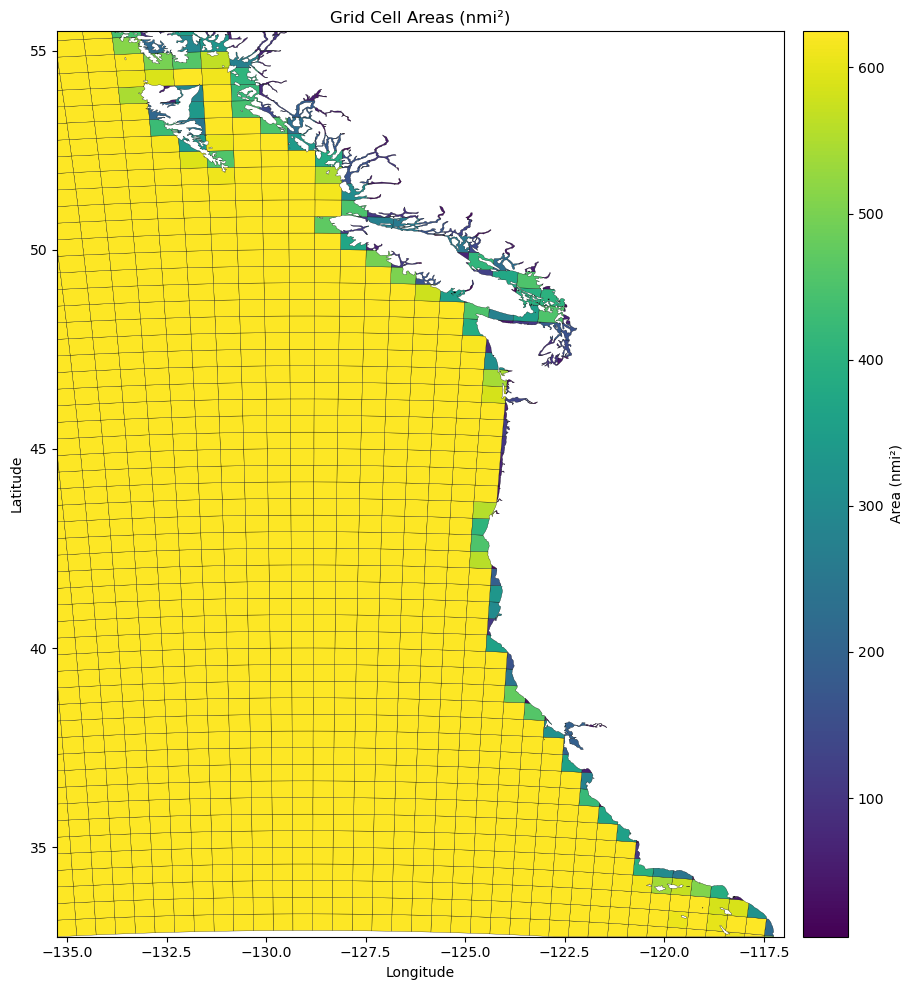

In [10]:
# Plot the grid
fig, ax = plot_grid(grid_cells, coastline, boundary)
plt.show()

In [11]:
ds_NASC1 = xr.open_zarr(NASC_path / "win_1720383165_1720385660_NASC.zarr")
ds_NASC1 = ep.consolidate.swap_dims_channel_frequency(ds_NASC1)
ds_NASC2 = xr.open_zarr(NASC_path / "win_1720383520_1720386015_NASC.zarr")
ds_NASC2 = ep.consolidate.swap_dims_channel_frequency(ds_NASC2)

In [12]:
# Gather some of the units
data_units = {
    "longitude": ds_NASC["longitude"].units,
    "latitude": ds_NASC["latitude"].units,
    "frequency": ds_NASC["frequency_nominal"].units,
}
data_units

{'longitude': 'degrees_east', 'latitude': 'degrees_north', 'frequency': 'Hz'}

In [13]:
pd.concat(
    [
        ds_NASC1.sum("depth").sel(frequency_nominal=38000).to_dataframe(),
        ds_NASC2.sum("depth").sel(frequency_nominal=38000).to_dataframe()
    ],
    ignore_index=True
)

,NASC,channel,frequency_nominal,latitude,longitude,ping_time
0,481.798913,WBT 400143-15 ES38B_ES,38000.0,38.937927,-124.668017,2024-07-07 20:14:12.500
1,0.000000,WBT 400143-15 ES38B_ES,38000.0,38.930290,-124.662634,2024-07-07 20:17:02.500
2,0.000000,WBT 400143-15 ES38B_ES,38000.0,38.923156,-124.657377,2024-07-07 20:19:42.500
3,0.000000,WBT 400143-15 ES38B_ES,38000.0,38.916030,-124.651439,2024-07-07 20:22:25.000
4,0.000000,WBT 400143-15 ES38B_ES,38000.0,38.909093,-124.645745,2024-07-07 20:25:05.000
5,970.573797,WBT 400143-15 ES38B_ES,38000.0,38.901812,-124.640067,2024-07-07 20:27:45.000
6,924.586852,WBT 400143-15 ES38B_ES,38000.0,38.894572,-124.634480,2024-07-07 20:30:27.500
7,1348.875233,WBT 400143-15 ES38B_ES,38000.0,38.887693,-124.629167,2024-07-07 20:33:02.500
8,0.000000,WBT 400143-15 ES38B_ES,38000.0,38.880541,-124.623726,2024-07-07 20:35:37.500
9,0.000000,WBT 400143-15 ES38B_ES,38000.0,38.873437,-124.618302,2024-07-07 20:38:12.500


In [14]:
from grid import create_boundary_gdf

In [15]:
boundary_gdf, boundary_gdf_utm, utm_num = create_boundary_gdf(
    bounds=GRID_PARAMS["bounds"], 
    projection=GRID_PARAMS["projection"]
)

In [16]:
boundary_gdf

,x,y,geometry
0,-135.25,32.75,POINT (-135.25 32.75)
1,-117.00,32.75,POINT (-117 32.75)
2,-117.00,55.50,POINT (-117 55.5)
3,-135.25,55.50,POINT (-135.25 55.5)
4,-135.25,32.75,POINT (-135.25 32.75)


In [17]:
boundary_gdf_utm

,x,y,geometry
0,-135.25,32.75,POINT (-85974.584 3640903.917)
1,-117.00,32.75,POINT (1627554.85 3688024.572)
2,-117.00,55.50,POINT (1256028.892 6216074.989)
3,-135.25,55.50,POINT (105465.154 6168196.203)
4,-135.25,32.75,POINT (-85974.584 3640903.917)


In [18]:
utm_num

32609

In [19]:
boundary_gdf.total_bounds

array([-135.25,   32.75, -117.  ,   55.5 ])

In [20]:
from core import GRID_PARAMS
from geopy.distance import distance
import geopandas as gpd

In [21]:
from shapely.geometry import box

In [22]:
GRID_PARAMS

{'bounds': {'latitude': [32.75, 55.5], 'longitude': [-135.25, -117.0]},
 'resolution': {'x_distance': 25.0, 'y_distance': 25.0},
 'projection': 'epsg:4326'}

In [23]:
# Define the step sizes
# ---- Define x step size
x_step = distance(nautical=GRID_PARAMS["resolution"]["x_distance"]).meters
# ---- Define y step size
y_step = distance(nautical=GRID_PARAMS["resolution"]["y_distance"]).meters


In [24]:
x_step, y_step

(46300.00000000001, 46300.00000000001)

In [25]:
xmin, ymin, xmax, ymax = boundary_gdf_utm.total_bounds
xmin, ymin, xmax, ymax

(-85974.58362681721, 3640903.916988396, 1627554.8503743797, 6216074.989180838)

In [26]:
# Generate the cells
grid_cells = []
# ---- Iterate through
for y0 in np.arange(ymin, ymax, y_step):
    for x0 in np.arange(xmin, xmax, x_step):
        x1 = x0 - x_step
        y1 = y0 + y_step
        grid_cells.append(box(x0, y0, x1, y1))


In [27]:
grid_cells

[<POLYGON ((-132274.584 3640903.917, -132274.584 3687203.917, -85974.584 3687...>,
 <POLYGON ((-85974.584 3640903.917, -85974.584 3687203.917, -39674.584 368720...>,
 <POLYGON ((-39674.584 3640903.917, -39674.584 3687203.917, 6625.416 3687203....>,
 <POLYGON ((6625.416 3640903.917, 6625.416 3687203.917, 52925.416 3687203.917...>,
 <POLYGON ((52925.416 3640903.917, 52925.416 3687203.917, 99225.416 3687203.9...>,
 <POLYGON ((99225.416 3640903.917, 99225.416 3687203.917, 145525.416 3687203....>,
 <POLYGON ((145525.416 3640903.917, 145525.416 3687203.917, 191825.416 368720...>,
 <POLYGON ((191825.416 3640903.917, 191825.416 3687203.917, 238125.416 368720...>,
 <POLYGON ((238125.416 3640903.917, 238125.416 3687203.917, 284425.416 368720...>,
 <POLYGON ((284425.416 3640903.917, 284425.416 3687203.917, 330725.416 368720...>,
 <POLYGON ((330725.416 3640903.917, 330725.416 3687203.917, 377025.416 368720...>,
 <POLYGON ((377025.416 3640903.917, 377025.416 3687203.917, 423325.416 368720...>,
 <PO

In [28]:
len(grid_cells)

2128

In [29]:
# Convert to a GeoDataFrame
cells_gdf = gpd.GeoDataFrame(grid_cells, columns=["geometry"], crs=GRID_PARAMS["projection"])

In [30]:
len(cells_gdf)

2128

In [31]:
# Get the centroids
cells_gdf["cell_centroid"] = cells_gdf["geometry"].centroid

/var/folders/1m/8nxc8r_900778tkhqfgh0nqh0000gn/T/ipykernel_77798/2764814461.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  cells_gdf["cell_centroid"] = cells_gdf["geometry"].centroid


In [32]:
df_NASC1 = ds_NASC1.sum("depth").sel(frequency_nominal=38000).to_dataframe().reset_index()
df_NASC1

,distance,NASC,channel,frequency_nominal,latitude,longitude,ping_time
0,0.0,481.798913,WBT 400143-15 ES38B_ES,38000.0,38.937927,-124.668017,2024-07-07 20:14:12.500
1,0.5,0.000000,WBT 400143-15 ES38B_ES,38000.0,38.930290,-124.662634,2024-07-07 20:17:02.500
2,1.0,0.000000,WBT 400143-15 ES38B_ES,38000.0,38.923156,-124.657377,2024-07-07 20:19:42.500
3,1.5,0.000000,WBT 400143-15 ES38B_ES,38000.0,38.916030,-124.651439,2024-07-07 20:22:25.000
4,2.0,0.000000,WBT 400143-15 ES38B_ES,38000.0,38.909093,-124.645745,2024-07-07 20:25:05.000
5,2.5,970.573797,WBT 400143-15 ES38B_ES,38000.0,38.901812,-124.640067,2024-07-07 20:27:45.000
6,3.0,924.586852,WBT 400143-15 ES38B_ES,38000.0,38.894572,-124.634480,2024-07-07 20:30:27.500
7,3.5,1348.875233,WBT 400143-15 ES38B_ES,38000.0,38.887693,-124.629167,2024-07-07 20:33:02.500
8,4.0,0.000000,WBT 400143-15 ES38B_ES,38000.0,38.880541,-124.623726,2024-07-07 20:35:37.500
9,4.5,0.000000,WBT 400143-15 ES38B_ES,38000.0,38.873437,-124.618302,2024-07-07 20:38:12.500


In [33]:
# Convert to GeoDataFrame
dataset_gdf = gpd.GeoDataFrame(
    data=df_NASC1,
    geometry=gpd.points_from_xy(df_NASC1["longitude"], df_NASC1["latitude"]),
    crs=GRID_PARAMS["projection"],
)
dataset_gdf

,distance,NASC,channel,frequency_nominal,latitude,longitude,ping_time,geometry
0,0.0,481.798913,WBT 400143-15 ES38B_ES,38000.0,38.937927,-124.668017,2024-07-07 20:14:12.500,POINT (-124.66802 38.93793)
1,0.5,0.000000,WBT 400143-15 ES38B_ES,38000.0,38.930290,-124.662634,2024-07-07 20:17:02.500,POINT (-124.66263 38.93029)
2,1.0,0.000000,WBT 400143-15 ES38B_ES,38000.0,38.923156,-124.657377,2024-07-07 20:19:42.500,POINT (-124.65738 38.92316)
3,1.5,0.000000,WBT 400143-15 ES38B_ES,38000.0,38.916030,-124.651439,2024-07-07 20:22:25.000,POINT (-124.65144 38.91603)
4,2.0,0.000000,WBT 400143-15 ES38B_ES,38000.0,38.909093,-124.645745,2024-07-07 20:25:05.000,POINT (-124.64575 38.90909)
5,2.5,970.573797,WBT 400143-15 ES38B_ES,38000.0,38.901812,-124.640067,2024-07-07 20:27:45.000,POINT (-124.64007 38.90181)
6,3.0,924.586852,WBT 400143-15 ES38B_ES,38000.0,38.894572,-124.634480,2024-07-07 20:30:27.500,POINT (-124.63448 38.89457)
7,3.5,1348.875233,WBT 400143-15 ES38B_ES,38000.0,38.887693,-124.629167,2024-07-07 20:33:02.500,POINT (-124.62917 38.88769)
8,4.0,0.000000,WBT 400143-15 ES38B_ES,38000.0,38.880541,-124.623726,2024-07-07 20:35:37.500,POINT (-124.62373 38.88054)
9,4.5,0.000000,WBT 400143-15 ES38B_ES,38000.0,38.873437,-124.618302,2024-07-07 20:38:12.500,POINT (-124.6183 38.87344)


In [34]:
dataset_gdf["geometry"].x

0    -124.668017
1    -124.662634
2    -124.657377
3    -124.651439
4    -124.645745
5    -124.640067
6    -124.634480
7    -124.629167
8    -124.623726
9    -124.618302
10   -124.612847
11   -124.607312
12   -124.601690
13   -124.595995
14   -124.590481
15   -124.585848
dtype: float64

In [35]:
# ---- To UTM
dataset_gdf = dataset_gdf.to_crs(f"epsg:{utm_num}")
dataset_gdf

,distance,NASC,channel,frequency_nominal,latitude,longitude,ping_time,geometry
0,0.0,481.798913,WBT 400143-15 ES38B_ES,38000.0,38.937927,-124.668017,2024-07-07 20:14:12.500,POINT (875517.28 4318819.627)
1,0.5,0.000000,WBT 400143-15 ES38B_ES,38000.0,38.930290,-124.662634,2024-07-07 20:17:02.500,POINT (876024.494 4317993.916)
2,1.0,0.000000,WBT 400143-15 ES38B_ES,38000.0,38.923156,-124.657377,2024-07-07 20:19:42.500,POINT (876518.312 4317223.492)
3,1.5,0.000000,WBT 400143-15 ES38B_ES,38000.0,38.916030,-124.651439,2024-07-07 20:22:25.000,POINT (877071.113 4316456.821)
4,2.0,0.000000,WBT 400143-15 ES38B_ES,38000.0,38.909093,-124.645745,2024-07-07 20:25:05.000,POINT (877601.884 4315710.127)
5,2.5,970.573797,WBT 400143-15 ES38B_ES,38000.0,38.901812,-124.640067,2024-07-07 20:27:45.000,POINT (878133.212 4314925.258)
6,3.0,924.586852,WBT 400143-15 ES38B_ES,38000.0,38.894572,-124.634480,2024-07-07 20:30:27.500,POINT (878656.481 4314144.575)
7,3.5,1348.875233,WBT 400143-15 ES38B_ES,38000.0,38.887693,-124.629167,2024-07-07 20:33:02.500,POINT (879154.191 4313402.864)
8,4.0,0.000000,WBT 400143-15 ES38B_ES,38000.0,38.880541,-124.623726,2024-07-07 20:35:37.500,POINT (879664.509 4312631.416)
9,4.5,0.000000,WBT 400143-15 ES38B_ES,38000.0,38.873437,-124.618302,2024-07-07 20:38:12.500,POINT (880173.194 4311865.211)


In [36]:
# Extract x- and y-coordinates
dataset_gdf["x"] = dataset_gdf["geometry"].x
dataset_gdf["y"] = dataset_gdf["geometry"].y

In [37]:
dataset_gdf

,distance,NASC,channel,frequency_nominal,latitude,longitude,ping_time,geometry,x,y
0,0.0,481.798913,WBT 400143-15 ES38B_ES,38000.0,38.937927,-124.668017,2024-07-07 20:14:12.500,POINT (875517.28 4318819.627),875517.279886,4.318820e+06
1,0.5,0.000000,WBT 400143-15 ES38B_ES,38000.0,38.930290,-124.662634,2024-07-07 20:17:02.500,POINT (876024.494 4317993.916),876024.494414,4.317994e+06
2,1.0,0.000000,WBT 400143-15 ES38B_ES,38000.0,38.923156,-124.657377,2024-07-07 20:19:42.500,POINT (876518.312 4317223.492),876518.312294,4.317223e+06
3,1.5,0.000000,WBT 400143-15 ES38B_ES,38000.0,38.916030,-124.651439,2024-07-07 20:22:25.000,POINT (877071.113 4316456.821),877071.112774,4.316457e+06
4,2.0,0.000000,WBT 400143-15 ES38B_ES,38000.0,38.909093,-124.645745,2024-07-07 20:25:05.000,POINT (877601.884 4315710.127),877601.883811,4.315710e+06
5,2.5,970.573797,WBT 400143-15 ES38B_ES,38000.0,38.901812,-124.640067,2024-07-07 20:27:45.000,POINT (878133.212 4314925.258),878133.211889,4.314925e+06
6,3.0,924.586852,WBT 400143-15 ES38B_ES,38000.0,38.894572,-124.634480,2024-07-07 20:30:27.500,POINT (878656.481 4314144.575),878656.480966,4.314145e+06
7,3.5,1348.875233,WBT 400143-15 ES38B_ES,38000.0,38.887693,-124.629167,2024-07-07 20:33:02.500,POINT (879154.191 4313402.864),879154.191002,4.313403e+06
8,4.0,0.000000,WBT 400143-15 ES38B_ES,38000.0,38.880541,-124.623726,2024-07-07 20:35:37.500,POINT (879664.509 4312631.416),879664.509080,4.312631e+06
9,4.5,0.000000,WBT 400143-15 ES38B_ES,38000.0,38.873437,-124.618302,2024-07-07 20:38:12.500,POINT (880173.194 4311865.211),880173.194249,4.311865e+06


In [38]:
len(dataset_gdf)

16

In [39]:
# Bin the longitude data
pd.cut(
    dataset_gdf["x"],
    np.arange(xmin, xmax + x_step, x_step),
    right=False,
    labels=np.arange(1, len(np.arange(xmin, xmax + x_step, x_step))),
).astype(int)


0     21
1     21
2     21
3     21
4     21
5     21
6     21
7     21
8     21
9     21
10    21
11    21
12    21
13    21
14    21
15    21
Name: x, dtype: int64

In [40]:
# Bin the latitude data
(
    pd.cut(
        dataset_gdf["y"],
        np.arange(ymin, ymax + y_step, y_step),
        right=True,
        labels=range(len(np.arange(ymin, ymax + y_step, y_step)) - 1),
    ).astype(int)
    + 1
)

0     15
1     15
2     15
3     15
4     15
5     15
6     15
7     15
8     15
9     15
10    15
11    15
12    15
13    15
14    15
15    15
Name: y, dtype: int64

In [41]:
range(len(np.arange(ymin, ymax + y_step, y_step)) - 1)

range(0, 56)

In [42]:
pd.cut(
    dataset_gdf["y"],
    np.arange(ymin, ymax + y_step, y_step),
    right=True,
    labels=np.arange(1, len(np.arange(ymin, ymax + y_step, y_step))),
).astype(int)

0     15
1     15
2     15
3     15
4     15
5     15
6     15
7     15
8     15
9     15
10    15
11    15
12    15
13    15
14    15
15    15
Name: y, dtype: int64

In [43]:
# Bin the longitude data
pd.cut(
    dataset_gdf["x"],
    np.arange(xmin, xmax + x_step, x_step),
    right=False,
    labels=np.arange(1, len(np.arange(xmin, xmax + x_step, x_step))),
).astype(int)


0     21
1     21
2     21
3     21
4     21
5     21
6     21
7     21
8     21
9     21
10    21
11    21
12    21
13    21
14    21
15    21
Name: x, dtype: int64

In [44]:
# Bin the longitude data
dataset_gdf["grid_x"] = pd.cut(
    dataset_gdf["x"],
    np.arange(xmin, xmax + x_step, x_step),
    right=False,
    labels=np.arange(1, len(np.arange(xmin, xmax + x_step, x_step))),
).astype(int)

# Bin the latitude data
dataset_gdf["grid_y"] = pd.cut(
    dataset_gdf["y"],
    np.arange(ymin, ymax + y_step, y_step),
    right=True,
    labels=np.arange(1, len(np.arange(ymin, ymax + y_step, y_step))),
).astype(int)


In [162]:
data_path = Path("/Users/wujung/code_git/echodataflow/temp_bio")
df_stratum = pd.read_csv(data_path / "inpfc_def.csv", index_col=0).reset_index().rename(columns={"stratum_num": "stratum"})
df_stratum

,stratum,latitude_northern_limit,stratum_name
0,1,36.0000,Conception
1,2,40.5000,Monterey
2,3,43.0000,Eureka
3,4,45.7667,South Columbia
4,5,48.5000,North Columbia - US/CAN border
5,6,55.0000,Canada


In [171]:
def add_stratum(df, df_stratum):
    # Create latitude bins from the stratum definitions
    lat_bins = [-90.0] + df_stratum["latitude_northern_limit"].tolist() + [90.0]
    lat_labels = df_stratum["stratum"].tolist() + [max(df_stratum["stratum"]) + 1]

    # Add stratum column based on latitude
    df["stratum"] = pd.cut(
        df["latitude"],
        bins=lat_bins,
        labels=lat_labels,
        include_lowest=True
    ).astype(int)

    return df

In [173]:
add_stratum(dataset_gdf, df_stratum)

,distance,NASC,channel,frequency_nominal,latitude,longitude,ping_time,geometry,x,y,grid_x,grid_y,stratum
0,0.0,481.798913,WBT 400143-15 ES38B_ES,38000.0,38.937927,-124.668017,2024-07-07 20:14:12.500,POINT (875517.28 4318819.627),875517.279886,4.318820e+06,21,15,2
1,0.5,0.000000,WBT 400143-15 ES38B_ES,38000.0,38.930290,-124.662634,2024-07-07 20:17:02.500,POINT (876024.494 4317993.916),876024.494414,4.317994e+06,21,15,2
2,1.0,0.000000,WBT 400143-15 ES38B_ES,38000.0,38.923156,-124.657377,2024-07-07 20:19:42.500,POINT (876518.312 4317223.492),876518.312294,4.317223e+06,21,15,2
3,1.5,0.000000,WBT 400143-15 ES38B_ES,38000.0,38.916030,-124.651439,2024-07-07 20:22:25.000,POINT (877071.113 4316456.821),877071.112774,4.316457e+06,21,15,2
4,2.0,0.000000,WBT 400143-15 ES38B_ES,38000.0,38.909093,-124.645745,2024-07-07 20:25:05.000,POINT (877601.884 4315710.127),877601.883811,4.315710e+06,21,15,2
5,2.5,970.573797,WBT 400143-15 ES38B_ES,38000.0,38.901812,-124.640067,2024-07-07 20:27:45.000,POINT (878133.212 4314925.258),878133.211889,4.314925e+06,21,15,2
6,3.0,924.586852,WBT 400143-15 ES38B_ES,38000.0,38.894572,-124.634480,2024-07-07 20:30:27.500,POINT (878656.481 4314144.575),878656.480966,4.314145e+06,21,15,2
7,3.5,1348.875233,WBT 400143-15 ES38B_ES,38000.0,38.887693,-124.629167,2024-07-07 20:33:02.500,POINT (879154.191 4313402.864),879154.191002,4.313403e+06,21,15,2
8,4.0,0.000000,WBT 400143-15 ES38B_ES,38000.0,38.880541,-124.623726,2024-07-07 20:35:37.500,POINT (879664.509 4312631.416),879664.509080,4.312631e+06,21,15,2
9,4.5,0.000000,WBT 400143-15 ES38B_ES,38000.0,38.873437,-124.618302,2024-07-07 20:38:12.500,POINT (880173.194 4311865.211),880173.194249,4.311865e+06,21,15,2


In [174]:
# Create boundary GeoDataFrame with UTM projection
gdf_boundary, gdf_boundary_utm, utm_num = create_boundary_gdf(
    bounds=GRID_PARAMS["bounds"], 
    projection=GRID_PARAMS["projection"]
)

# Create the full grid
gdf_grid_cells, gdf_coastline, _ = create_grid_from_bounds(
    bounds=GRID_PARAMS["bounds"], 
    resolution=GRID_PARAMS["resolution"],
    projection=GRID_PARAMS["projection"],
    coastline_resolution="10m",
    area_threshold=5
)


In [175]:
def NASC_dataset_to_dataframe(NASC_filenames: list) -> pd.DataFrame:
    """
    Combine NASC from multiple datasets into a single DataFrame.
    """
    df_NASC_list = []
    for nascf in NASC_filenames:
        ds_NASC = xr.open_zarr(nascf)
        ds_NASC = ep.consolidate.swap_dims_channel_frequency(ds_NASC)
        df_NASC_list.append(ds_NASC.sum("depth").sel(frequency_nominal=38000).to_dataframe())

    return pd.concat(df_NASC_list, ignore_index=True)

In [176]:
NASC_filenames = sorted(list(NASC_path.glob("*.zarr")))

In [177]:
df_NASC_combined = NASC_dataset_to_dataframe(NASC_filenames[:3])
df_NASC_combined

,NASC,channel,frequency_nominal,latitude,longitude,ping_time
0,0.000000,WBT 400143-15 ES38B_ES,38000.0,39.280826,-124.929718,2024-07-07 18:06:40.000000000
1,0.000000,WBT 400143-15 ES38B_ES,38000.0,39.273865,-124.924258,2024-07-07 18:09:22.500000000
2,0.000000,WBT 400143-15 ES38B_ES,38000.0,39.266657,-124.918675,2024-07-07 18:12:07.500000000
3,0.000000,WBT 400143-15 ES38B_ES,38000.0,39.259561,-124.913200,2024-07-07 18:14:50.000000000
4,0.000000,WBT 400143-15 ES38B_ES,38000.0,39.252463,-124.907738,2024-07-07 18:17:30.000000000
5,0.000000,WBT 400143-15 ES38B_ES,38000.0,39.245240,-124.902194,2024-07-07 18:20:15.000000000
6,0.000000,WBT 400143-15 ES38B_ES,38000.0,39.237972,-124.896636,2024-07-07 18:22:57.500000000
7,0.000000,WBT 400143-15 ES38B_ES,38000.0,39.231017,-124.891259,2024-07-07 18:25:37.500000000
8,0.000000,WBT 400143-15 ES38B_ES,38000.0,39.223842,-124.885657,2024-07-07 18:28:20.000000000
9,0.000000,WBT 400143-15 ES38B_ES,38000.0,39.216631,-124.880028,2024-07-07 18:31:07.500000000


In [178]:
def griddify_NASC(
    df_NASC: pd.DataFrame,
    utm_num: int,
    boundary_gdf_utm: gpd.GeoDataFrame,
    df_stratum: pd.DataFrame,
) -> gpd.GeoDataFrame:
    """
    Generate geodataframe with grid x/y containing NASC values.
    """
    # Convert to GeoDataFrame
    dataset_gdf = gpd.GeoDataFrame(
        data=df_NASC,
        geometry=gpd.points_from_xy(df_NASC["longitude"], df_NASC["latitude"]),
        crs=GRID_PARAMS["projection"],
    ).to_crs(f"epsg:{utm_num}")

    # Extract x y coordinate for pd.cut below
    dataset_gdf["utm_x"] = dataset_gdf["geometry"].x
    dataset_gdf["utm_y"] = dataset_gdf["geometry"].y

    # Get grid step sizes and boundary x/y
    x_step = distance(nautical=GRID_PARAMS["resolution"]["x_distance"]).meters
    y_step = distance(nautical=GRID_PARAMS["resolution"]["y_distance"]).meters
    xmin, ymin, xmax, ymax = boundary_gdf_utm.total_bounds

    # Bin longitude and latitude into grids
    dataset_gdf["grid_x"] = pd.cut(
        dataset_gdf["utm_x"],
        np.arange(xmin, xmax + x_step, x_step),
        right=False,
        labels=np.arange(1, len(np.arange(xmin, xmax + x_step, x_step))),
    ).astype(int)

    # Bin the latitude data
    dataset_gdf["grid_y"] = pd.cut(
        dataset_gdf["utm_y"],
        np.arange(ymin, ymax + y_step, y_step),
        right=True,
        labels=np.arange(1, len(np.arange(ymin, ymax + y_step, y_step))),
    ).astype(int)

    # Add stratum info
    dataset_gdf = add_stratum(dataset_gdf, df_stratum)

    return dataset_gdf

In [179]:
gdf_NASC = griddify_NASC(
    df_NASC=df_NASC_combined,
    utm_num=utm_num,
    boundary_gdf_utm=boundary_gdf_utm,
    df_stratum=df_stratum
)

In [180]:
gdf_NASC.head(10)

,NASC,channel,frequency_nominal,latitude,longitude,ping_time,geometry,utm_x,utm_y,grid_x,grid_y,stratum
0,0.0,WBT 400143-15 ES38B_ES,38000.0,39.280826,-124.929718,2024-07-07 18:06:40.000,POINT (851114.485 4355844.275),851114.484955,4.355844e+06,21,16,2
1,0.0,WBT 400143-15 ES38B_ES,38000.0,39.273865,-124.924258,2024-07-07 18:09:22.500,POINT (851620.513 4355092.589),851620.512607,4.355093e+06,21,16,2
2,0.0,WBT 400143-15 ES38B_ES,38000.0,39.266657,-124.918675,2024-07-07 18:12:07.500,POINT (852138.435 4354314.043),852138.435295,4.354314e+06,21,16,2
3,0.0,WBT 400143-15 ES38B_ES,38000.0,39.259561,-124.913200,2024-07-07 18:14:50.000,POINT (852646.626 4353547.54),852646.625819,4.353548e+06,21,16,2
4,0.0,WBT 400143-15 ES38B_ES,38000.0,39.252463,-124.907738,2024-07-07 18:17:30.000,POINT (853153.767 4352780.718),853153.766752,4.352781e+06,21,16,2
5,0.0,WBT 400143-15 ES38B_ES,38000.0,39.245240,-124.902194,2024-07-07 18:20:15.000,POINT (853668.723 4352000.438),853668.723351,4.352000e+06,21,16,2
6,0.0,WBT 400143-15 ES38B_ES,38000.0,39.237972,-124.896636,2024-07-07 18:22:57.500,POINT (854185.244 4351215.184),854185.244256,4.351215e+06,21,16,2
7,0.0,WBT 400143-15 ES38B_ES,38000.0,39.231017,-124.891259,2024-07-07 18:25:37.500,POINT (854684.574 4350464.059),854684.574055,4.350464e+06,21,16,2
8,0.0,WBT 400143-15 ES38B_ES,38000.0,39.223842,-124.885657,2024-07-07 18:28:20.000,POINT (855204.615 4349689.374),855204.615048,4.349689e+06,21,16,2
9,0.0,WBT 400143-15 ES38B_ES,38000.0,39.216631,-124.880028,2024-07-07 18:31:07.500,POINT (855727.153 4348910.838),855727.152551,4.348911e+06,21,16,2


In [181]:
gdf_grid_cells

,geometry,grid_x,grid_y,area
0,"POLYGON ((-117.25452 32.76713, -117.25388 32.7...",38,1,491.943240
1,"POLYGON ((-117.4894 32.78924, -117.49448 32.75...",37,1,625.000000
2,"POLYGON ((-118.44992 32.81882, -118.43837 32.8...",36,1,610.460377
3,"POLYGON ((-118.51361 32.88037, -118.5086 32.87...",35,1,620.304729
4,"POLYGON ((-118.94753 32.9164, -118.96635 32.75...",34,1,625.000000
...,...,...,...,...
1165,"POLYGON ((-135.24446 54.8394, -135.18116 54.42...",5,53,625.000000
1166,"POLYGON ((-134.52703 54.87429, -134.47091 54.4...",6,53,625.000000
1167,"POLYGON ((-135.24446 54.8394, -135.25 54.83909...",5,54,625.000000
1168,"POLYGON ((-134.58461 55.2884, -134.52703 54.87...",6,54,625.000000


In [138]:
from flows_biology import (
    get_count_from_length_specimen, 
    get_length_weight_regression,
    get_sigma_bs_mean_stratum,
    get_weight_mean_stratum
)

In [189]:
date_prefix = "202407"
species_code = "22500"  # Pacific herring
haul_num = 11

print(f"Processing haul number {haul_num} for {date_prefix} with species code {species_code}.")

# Consolidate length count for each haul
df_length = pd.read_csv(
    csv_path / f"{date_prefix}_{species_code}_{haul_num:03d}_lf.csv", index_col=0
)
df_specimen = pd.read_csv(
    csv_path / f"{date_prefix}_{species_code}_{haul_num:03d}_spec.csv", index_col=0
)
df_length_count = get_count_from_length_specimen(df_length, df_specimen)

# Add haul number and lat/lon for downstream stratification
df_info = pd.read_csv(
    csv_path / f"{date_prefix}_{haul_num:03d}_operation_info.csv", index_col=0
).rename(
    columns={
        "td_timestamp": "timestamp",
        "td_latitude": "latitude",
        "td_longitude": "longitude",
    },
).reset_index()  # reset index to get operation_number into a column
df_specimen = pd.merge(
    df_specimen,
    df_info,
    how="cross"  # create all possible combinations, but we only have 1 row here
)
df_length_count = pd.merge(
    df_length_count,
    df_info, 
    how="cross"  # create all possible combinations, but we only have 1 row here
)

# Add stratrum info to df_specimen and df_length_count based on latitude
df_stratum = pd.read_csv(data_path / "inpfc_def.csv", index_col=0).reset_index().rename(
    columns={"stratum_num": "stratum"}
)
df_specimen = add_stratum(df_specimen, df_stratum)
df_length_count = add_stratum(df_length_count, df_stratum)

# Compute length-weight relationship for each stratum
# Separately for: male, female, all fish combined
df_length_weight_regression = get_length_weight_regression(df_specimen)

# Compute mean sigma_bs and mean weight for each stratum
# columns: stratum, sigma_bs_mean, weight_mean
df_stratum = pd.merge(
    df_stratum,
    get_sigma_bs_mean_stratum(df_length_count),
    on="stratum",
    how="outer"
)
df_stratum = pd.merge(
    df_stratum,
    get_weight_mean_stratum(df_length_count, df_length_weight_regression),
    on="stratum",
    how="outer"
)

Processing haul number 11 for 202407 with species code 22500.


In [190]:
df_stratum

,stratum,latitude_northern_limit,stratum_name,sigma_bs_mean,weight_mean
0,1,36.0000,Conception,NaN,NaN
1,2,40.5000,Monterey,0.00012,0.138422
2,3,43.0000,Eureka,NaN,NaN
3,4,45.7667,South Columbia,NaN,NaN
4,5,48.5000,North Columbia - US/CAN border,NaN,NaN
5,6,55.0000,Canada,NaN,NaN


In [192]:
df_stratum

,stratum,latitude_northern_limit,stratum_name,sigma_bs_mean,weight_mean
0,1,36.0000,Conception,NaN,NaN
1,2,40.5000,Monterey,0.00012,0.138422
2,3,43.0000,Eureka,NaN,NaN
3,4,45.7667,South Columbia,NaN,NaN
4,5,48.5000,North Columbia - US/CAN border,NaN,NaN
5,6,55.0000,Canada,NaN,NaN


In [196]:
# Merge on stratum 
gdf_NASC = gdf_NASC.merge(
    df_stratum[["stratum", "sigma_bs_mean", "weight_mean"]],
    on="stratum",  # merge on stratum 
    how="left"
)

In [198]:
gdf_NASC.head(5)

,NASC,channel,frequency_nominal,latitude,longitude,ping_time,geometry,utm_x,utm_y,grid_x,grid_y,stratum,sigma_bs_mean_x,weight_mean_x,number_density,biomass_density,sigma_bs_mean_y,weight_mean_y,sigma_bs_mean,weight_mean
0,0.0,WBT 400143-15 ES38B_ES,38000.0,39.280826,-124.929718,2024-07-07 18:06:40.000,POINT (851114.485 4355844.275),851114.484955,4.355844e+06,21,16,2,0.00012,0.138422,0.0,0.0,0.00012,0.138422,0.00012,0.138422
1,0.0,WBT 400143-15 ES38B_ES,38000.0,39.273865,-124.924258,2024-07-07 18:09:22.500,POINT (851620.513 4355092.589),851620.512607,4.355093e+06,21,16,2,0.00012,0.138422,0.0,0.0,0.00012,0.138422,0.00012,0.138422
2,0.0,WBT 400143-15 ES38B_ES,38000.0,39.266657,-124.918675,2024-07-07 18:12:07.500,POINT (852138.435 4354314.043),852138.435295,4.354314e+06,21,16,2,0.00012,0.138422,0.0,0.0,0.00012,0.138422,0.00012,0.138422
3,0.0,WBT 400143-15 ES38B_ES,38000.0,39.259561,-124.913200,2024-07-07 18:14:50.000,POINT (852646.626 4353547.54),852646.625819,4.353548e+06,21,16,2,0.00012,0.138422,0.0,0.0,0.00012,0.138422,0.00012,0.138422
4,0.0,WBT 400143-15 ES38B_ES,38000.0,39.252463,-124.907738,2024-07-07 18:17:30.000,POINT (853153.767 4352780.718),853153.766752,4.352781e+06,21,16,2,0.00012,0.138422,0.0,0.0,0.00012,0.138422,0.00012,0.138422


In [199]:
gdf_NASC["number_density"] = gdf_NASC["NASC"] / gdf_NASC["sigma_bs_mean"]

In [202]:
gdf_NASC["biomass_density"] = gdf_NASC["number_density"] * gdf_NASC["weight_mean"]

In [203]:
gdf_grid_cells

,geometry,grid_x,grid_y,area
0,"POLYGON ((-117.25452 32.76713, -117.25388 32.7...",38,1,491.943240
1,"POLYGON ((-117.4894 32.78924, -117.49448 32.75...",37,1,625.000000
2,"POLYGON ((-118.44992 32.81882, -118.43837 32.8...",36,1,610.460377
3,"POLYGON ((-118.51361 32.88037, -118.5086 32.87...",35,1,620.304729
4,"POLYGON ((-118.94753 32.9164, -118.96635 32.75...",34,1,625.000000
...,...,...,...,...
1165,"POLYGON ((-135.24446 54.8394, -135.18116 54.42...",5,53,625.000000
1166,"POLYGON ((-134.52703 54.87429, -134.47091 54.4...",6,53,625.000000
1167,"POLYGON ((-135.24446 54.8394, -135.25 54.83909...",5,54,625.000000
1168,"POLYGON ((-134.58461 55.2884, -134.52703 54.87...",6,54,625.000000


In [206]:
gdf_NASC.groupby(["grid_x", "grid_y"])["number_density"].mean()

grid_x  grid_y
21      15        609774.938248
        16         21212.302098
Name: number_density, dtype: float64

In [213]:
gdf_grid_cells.set_index(["grid_x", "grid_y"], inplace=True)

In [215]:
gdf_grid_cells = pd.merge(
    gdf_grid_cells,
    gdf_NASC.groupby(["grid_x", "grid_y"])["number_density"].mean(),
    on=["grid_x", "grid_y"],
    how="left"
)

In [217]:
gdf_NASC.groupby(["grid_x", "grid_y"])["number_density"].mean()

grid_x  grid_y
21      15        609774.938248
        16         21212.302098
Name: number_density, dtype: float64

In [216]:
gdf_grid_cells.loc[[(21, 15), (21, 16)]]

geometry   area  \
grid_x grid_y                                                             
21     15      POLYGON ((-125.06825 39.10149, -125.09117 38.6...  625.0   
       16      POLYGON ((-125.04485 39.51771, -125.06825 39.1...  625.0   

               number_density  
grid_x grid_y                  
21     15       609774.938248  
       16        21212.302098

In [218]:
gdf_grid_cells = pd.merge(
    gdf_grid_cells,
    gdf_NASC.groupby(["grid_x", "grid_y"])["biomass_density"].mean(),
    on=["grid_x", "grid_y"],
    how="left"
)

In [219]:
gdf_grid_cells["abundance"] = gdf_grid_cells["number_density"] * gdf_grid_cells["area"]
gdf_grid_cells["biomass"] = gdf_grid_cells["biomass_density"] * gdf_grid_cells["area"]

In [220]:
gdf_grid_cells

,,geometry,area,number_density,biomass_density,abundance,biomass
grid_x,grid_y,,,,,,
38,1,"POLYGON ((-117.25452 32.76713, -117.25388 32.7...",491.943240,NaN,NaN,NaN,NaN
37,1,"POLYGON ((-117.4894 32.78924, -117.49448 32.75...",625.000000,NaN,NaN,NaN,NaN
36,1,"POLYGON ((-118.44992 32.81882, -118.43837 32.8...",610.460377,NaN,NaN,NaN,NaN
35,1,"POLYGON ((-118.51361 32.88037, -118.5086 32.87...",620.304729,NaN,NaN,NaN,NaN
34,1,"POLYGON ((-118.94753 32.9164, -118.96635 32.75...",625.000000,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
5,53,"POLYGON ((-135.24446 54.8394, -135.18116 54.42...",625.000000,NaN,NaN,NaN,NaN
6,53,"POLYGON ((-134.52703 54.87429, -134.47091 54.4...",625.000000,NaN,NaN,NaN,NaN
5,54,"POLYGON ((-135.24446 54.8394, -135.25 54.83909...",625.000000,NaN,NaN,NaN,NaN


In [221]:
gdf_grid_cells.loc[[(21, 15), (21, 16)]]

geometry   area  \
grid_x grid_y                                                             
21     15      POLYGON ((-125.06825 39.10149, -125.09117 38.6...  625.0   
       16      POLYGON ((-125.04485 39.51771, -125.06825 39.1...  625.0   

               number_density  biomass_density     abundance       biomass  
grid_x grid_y                                                               
21     15       609774.938248     84406.499979  3.811093e+08  5.275406e+07  
       16        21212.302098      2936.257403  1.325769e+07  1.835161e+06

In [222]:
609774.938248 * 625.0

381109336.405

In [223]:
84406.499979 * 625.0

52754062.486875